In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
calendar = pd.read_csv("../data/calendar.csv")
sales = pd.read_csv("../data/sales_train_validation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
submission = pd.read_csv("../data/sample_submission.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [3]:
sales_sample = sales.head(500).copy()

In [4]:
print("Calendar:", calendar.shape)
print("Sales:", sales.shape)
print("Prices:", prices.shape)
print("Submission:", submission.shape)

Calendar: (1969, 14)
Sales: (30490, 1919)
Prices: (6841121, 4)
Submission: (60980, 29)


In [5]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [6]:
sales_sample.head()

id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  d_10  d_11  d_12  \
0       CA    0    0    0    0    0    0    0    0    0     0     0     0   
1       CA    0    0    0    0    0    0    0    0    0     0     0     0   
2       CA    0    0    0    0    0    0    0    0    0     0     0     0   
3       CA    0    0    0    0    0    0    0    0    0     0     0     0   
4       CA    0    0    0    0    0    0    0    0    0     0     0     0   

   d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  d_21  d_22  d_23  d_24  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_25  d_26  d_27  d_28  d_29  d_30  d_31  d_32  d_33  d_34  d_35  d_36  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  d_45  d_46  d_47  d_48  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     2     0     0     0     2     0     1     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_49  d_50  d_51  d_52  d_53  d_54  d_55  d_56  d_57  d_58  d_59  d_60  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     2     0     1     0     0     1     1     1     0     2     3   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_61  d_62  d_63  d_64  d_65  d_66  d_67  d_68  d_69  d_70  d_71  d_72  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     1     0     0     0     0     0     1     0     0     1     1     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_73  d_74  d_75  d_76  d_77  d_78  d_79  d_80  d_81  d_82  d_83  d_84  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     1     0     0     1     2     3     0     2     0     0     2   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_85  d_86  d_87  d_88  d_89  d_90  d_91  d_92  d_93  d_94  d_95  d_96  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   


In [7]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [8]:
submission.head()

,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,HOBBIES_1_001_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,HOBBIES_1_004_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_005_CA_1_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [10]:
sales_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 7.3 MB


In [11]:
prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 208.8 MB


In [12]:
calendar.isnull().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [13]:
sales_sample.isnull().sum()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1909      0
d_1910      0
d_1911      0
d_1912      0
d_1913      0
Length: 1919, dtype: int64

In [14]:
prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [15]:
calendar['date'] = pd.to_datetime(calendar['date'])

calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[us]
 1   wm_yr_wk      1969 non-null   int64         
 2   weekday       1969 non-null   str           
 3   wday          1969 non-null   int64         
 4   month         1969 non-null   int64         
 5   year          1969 non-null   int64         
 6   d             1969 non-null   str           
 7   event_name_1  162 non-null    str           
 8   event_type_1  162 non-null    str           
 9   event_name_2  5 non-null      str           
 10  event_type_2  5 non-null      str           
 11  snap_CA       1969 non-null   int64         
 12  snap_TX       1969 non-null   int64         
 13  snap_WI       1969 non-null   int64         
dtypes: datetime64[us](1), int64(7), str(6)
memory usage: 215.5 KB


In [16]:
calendar['event_name_1'] = calendar['event_name_1'].fillna('No Event')
calendar['event_type_1'] = calendar['event_type_1'].fillna('No Event')

calendar['event_name_2'] = calendar['event_name_2'].fillna('No Event')
calendar['event_type_2'] = calendar['event_type_2'].fillna('No Event')

In [17]:
calendar.isnull().sum()

date            0
wm_yr_wk        0
weekday         0
wday            0
month           0
year            0
d               0
event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
snap_CA         0
snap_TX         0
snap_WI         0
dtype: int64

In [18]:
print("Calendar duplicates :", calendar.duplicated().sum())

print("Sales duplicates :", sales.duplicated().sum())

print("Prices duplicates :", prices.duplicated().sum())

Calendar duplicates : 0
Sales duplicates : 0
Prices duplicates : 0


In [19]:
sales_sample.describe()

d_1         d_2         d_3         d_4         d_5         d_6  \
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000   
mean     1.088000    0.992000    0.830000    0.778000    0.536000    0.920000   
std      4.430747    4.566579    4.207673    2.991088    2.160101    4.370332   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
75%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
max     54.000000   73.000000   67.000000   33.000000   29.000000   74.000000   

              d_7         d_8         d_9        d_10        d_11        d_12  \
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000   
mean     0.690000    1.514000    0.860000    0.762000    0.974000    0.788000   
std      2.454781    6.177226    3.212638    3.384119    4.190518    3.223016   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
75%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
max     26.000000   78.000000   30.000000   36.000000   48.000000   28.000000   

             d_13        d_14        d_15        d_16        d_17        d_18  \
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000   
mean     0.902000    0.900000    1.360000    0.912000    0.756000    0.654000   
std      3.712136    3.242689    5.915775    3.405209    3.235646    2.599191   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
75%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
max     52.000000   33.000000   81.000000   35.000000   37.000000   31.000000   

             d_19        d_20        d_21        d_22        d_23        d_24  \
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000   
mean     0.540000    0.540000    0.590000    1.574000    0.984000    1.250000   
std      2.635582    2.816428    2.779452    6.267942    4.054704    4.915672   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
75%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
max     40.000000   51.000000   52.000000   85.000000   54.000000   54.000000   

             d_25        d_26        d_27        d_28        d_29        d_30  \
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000   
mean     0.910000    0.824000    0.844000    0.792000    1.212000    0.410000   
std      4.614812    4.211948    3.717971    3.592011    4.815125    1.115522   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
75%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
max     73.000000   68.000000   35.000000   40.000000   64.000000    9.000000   

            d_31        d_32        d_33        d_34        d_35        d_36  \
count  500.00000  500.000000  500.000000  500.000000  500.000000  500.000000   
mean     0.34800    0.458000    0.384000    0.336000    0.366000    0.590000   
std      1.00644    1.514207    1.729313    1.024306    1.211189    1.893428   
min      0.00000    0.000000    0.000000    

In [20]:
prices.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


In [21]:
sales_sample['cat_id'].unique()

<StringArray>
['HOBBIES']
Length: 1, dtype: str

In [22]:
sales['store_id'].unique()

<StringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str

In [23]:
sales['state_id'].unique()

<StringArray>
['CA', 'TX', 'WI']
Length: 3, dtype: str

In [24]:
sales_copy = sales.copy()

In [25]:
id_columns = [
    'id',
    'item_id',
    'dept_id',
    'cat_id',
    'store_id',
    'state_id'
]

In [26]:
sales_long = sales_sample.melt(
    id_vars=id_columns,
    var_name='d',
    value_name='sales'
)


In [27]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [28]:
sales_long.shape

(956500, 8)

In [29]:
sales_calendar = sales_long.merge(
    calendar,
    on='d',
    how='left'
)

In [30]:
sales_calendar.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0


In [31]:
sales_final = sales_calendar.merge(
    prices,
    on=['store_id', 'item_id', 'wm_yr_wk'],
    how='left'
)

In [32]:
sales_final.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN


In [33]:
sales_final.shape

(956500, 22)

In [34]:
sales_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 956500 entries, 0 to 956499
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            956500 non-null  str           
 1   item_id       956500 non-null  str           
 2   dept_id       956500 non-null  str           
 3   cat_id        956500 non-null  str           
 4   store_id      956500 non-null  str           
 5   state_id      956500 non-null  str           
 6   d             956500 non-null  str           
 7   sales         956500 non-null  int64         
 8   date          956500 non-null  datetime64[us]
 9   wm_yr_wk      956500 non-null  int64         
 10  weekday       956500 non-null  str           
 11  wday          956500 non-null  int64         
 12  month         956500 non-null  int64         
 13  year          956500 non-null  int64         
 14  event_name_1  956500 non-null  str           
 15  event_type_1  956500 non-nul

In [35]:
sales_final.isnull().sum()

id                   0
item_id              0
dept_id              0
cat_id               0
store_id             0
state_id             0
d                    0
sales                0
date                 0
wm_yr_wk             0
weekday              0
wday                 0
month                0
year                 0
event_name_1         0
event_type_1         0
event_name_2         0
event_type_2         0
snap_CA              0
snap_TX              0
snap_WI              0
sell_price      179984
dtype: int64

In [36]:
sales_final = sales_calendar.merge(
    prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

In [37]:
sales_final.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN


In [38]:
sales_final.shape

(956500, 22)

In [39]:
sales_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 956500 entries, 0 to 956499
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            956500 non-null  str           
 1   item_id       956500 non-null  str           
 2   dept_id       956500 non-null  str           
 3   cat_id        956500 non-null  str           
 4   store_id      956500 non-null  str           
 5   state_id      956500 non-null  str           
 6   d             956500 non-null  str           
 7   sales         956500 non-null  int64         
 8   date          956500 non-null  datetime64[us]
 9   wm_yr_wk      956500 non-null  int64         
 10  weekday       956500 non-null  str           
 11  wday          956500 non-null  int64         
 12  month         956500 non-null  int64         
 13  year          956500 non-null  int64         
 14  event_name_1  956500 non-null  str           
 15  event_type_1  956500 non-nul

In [40]:
sales_final.isnull().sum()

id                   0
item_id              0
dept_id              0
cat_id               0
store_id             0
state_id             0
d                    0
sales                0
date                 0
wm_yr_wk             0
weekday              0
wday                 0
month                0
year                 0
event_name_1         0
event_type_1         0
event_name_2         0
event_type_2         0
snap_CA              0
snap_TX              0
snap_WI              0
sell_price      179984
dtype: int64

In [41]:
sales_final["date"] = pd.to_datetime(sales_final["date"])

In [42]:
sales_final["date"].dtype

dtype('<M8[us]')

In [43]:
sales_final.to_csv(
    "../data/sales_final_sample.csv",
    index=False
)

In [44]:
# Exploratory Data Analysis

In [45]:
daily_sales = (
    sales_final
    .groupby("date")["sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,date,sales
0,2011-01-29,544
1,2011-01-30,496
2,2011-01-31,415
3,2011-02-01,389
4,2011-02-02,268


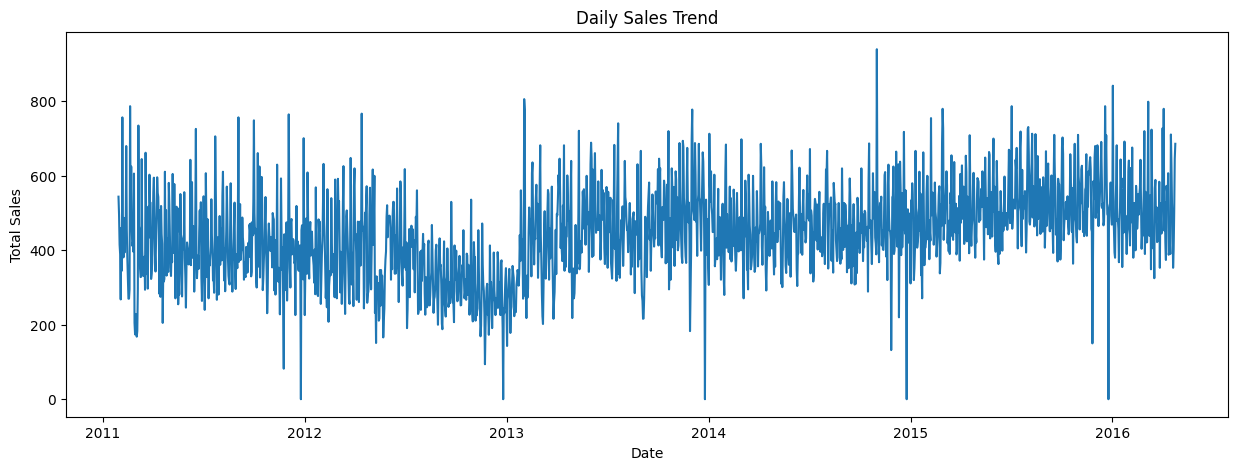

In [46]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

In [47]:
category_sales = (
    sales_final
    .groupby("cat_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

cat_id
HOBBIES    851737
Name: sales, dtype: int64

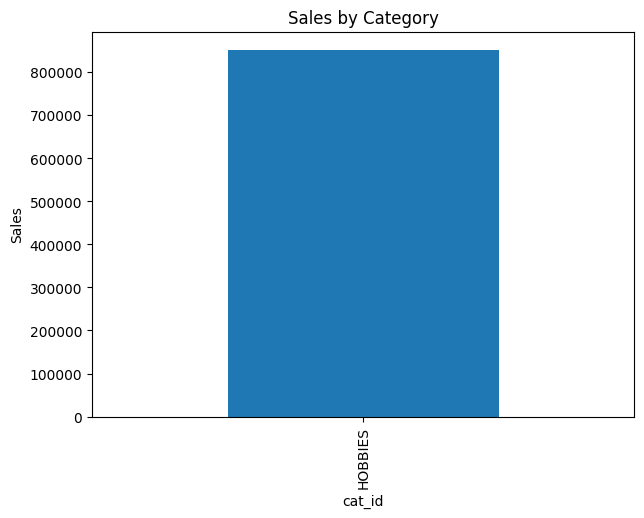

In [48]:
plt.figure(figsize=(7,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.ylabel("Sales")

plt.show()

In [49]:
state_sales = (
    sales_final
    .groupby("state_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

state_sales

state_id
CA    851737
Name: sales, dtype: int64

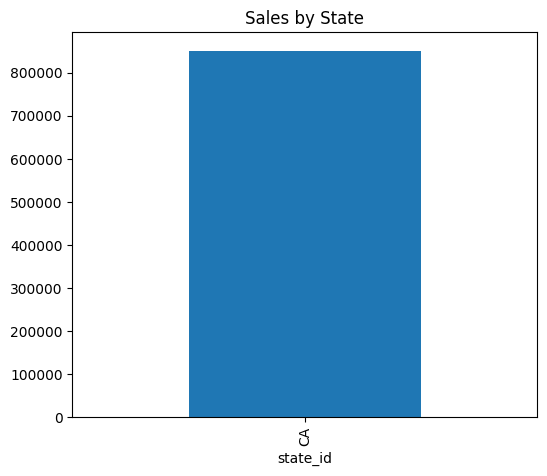

In [50]:
plt.figure(figsize=(6,5))

state_sales.plot(kind="bar")

plt.title("Sales by State")

plt.show()

In [51]:
store_sales = (
    sales_final
    .groupby("store_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales

store_id
CA_1    851737
Name: sales, dtype: int64

In [52]:
monthly_sales = (
    sales_final
    .groupby("month")["sales"]
    .sum()
)

monthly_sales

month
1     68273
2     77340
3     82087
4     81310
5     67891
6     69844
7     69476
8     69432
9     63680
10    69349
11    64498
12    68557
Name: sales, dtype: int64

In [53]:
weekday_sales = (
    sales_final
    .groupby("weekday")["sales"]
    .sum()
)

weekday_sales

weekday
Friday       125580
Monday       115081
Saturday     152549
Sunday       134678
Thursday     107579
Tuesday      108879
Wednesday    107391
Name: sales, dtype: int64

In [54]:
sales_final["year"] = sales_final["date"].dt.year
sales_final["month"] = sales_final["date"].dt.month
sales_final["day"] = sales_final["date"].dt.day
sales_final["day_of_week"] = sales_final["date"].dt.dayofweek
sales_final["week"] = sales_final["date"].dt.isocalendar().week
sales_final["quarter"] = sales_final["date"].dt.quarter

In [55]:
sales_final[
    [
        "date",
        "year",
        "month",
        "day",
        "day_of_week",
        "week",
        "quarter"
    ]
].head()

,date,year,month,day,day_of_week,week,quarter
0,2011-01-29,2011,1,29,5,4,1
1,2011-01-29,2011,1,29,5,4,1
2,2011-01-29,2011,1,29,5,4,1
3,2011-01-29,2011,1,29,5,4,1
4,2011-01-29,2011,1,29,5,4,1


In [56]:
sales_final["is_weekend"] = sales_final["day_of_week"].isin([5,6]).astype(int)

In [57]:
sales_final[["date","day_of_week","is_weekend"]].head(10)

,date,day_of_week,is_weekend
0,2011-01-29,5,1
1,2011-01-29,5,1
2,2011-01-29,5,1
3,2011-01-29,5,1
4,2011-01-29,5,1
5,2011-01-29,5,1
6,2011-01-29,5,1
7,2011-01-29,5,1
8,2011-01-29,5,1
9,2011-01-29,5,1


In [58]:
sales_final["has_event"] = sales_final["event_name_1"].notnull().astype(int)


In [59]:
sales_final[["date","event_name_1","has_event"]].head(20)

,date,event_name_1,has_event
0,2011-01-29,No Event,1
1,2011-01-29,No Event,1
2,2011-01-29,No Event,1
3,2011-01-29,No Event,1
4,2011-01-29,No Event,1
5,2011-01-29,No Event,1
6,2011-01-29,No Event,1
7,2011-01-29,No Event,1
8,2011-01-29,No Event,1
9,2011-01-29,No Event,1


In [60]:
sales_final["snap"] = (
    sales_final["snap_CA"] +
    sales_final["snap_TX"] +
    sales_final["snap_WI"]
)

In [61]:
sales_final["snap"].value_counts()

snap
0    484000
2    220500
3    126000
1    126000
Name: count, dtype: int64

In [62]:
sales_final.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'day', 'day_of_week',
       'week', 'quarter', 'is_weekend', 'has_event', 'snap'],
      dtype='str')